<a href="https://colab.research.google.com/github/yutongzou07/microvan-consumer-segmentation-strategy/blob/main/Microvan_Case_Team_33_Pt4_Done_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



#PART0 Data Preparation




In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# Step 0: Read the data
microvan = pd.read_csv("microvan.csv")
microvan.head()

,subjnumb,mvliking,kidtrans,miniboxy,lthrbetr,secbiggr,safeimpt,buyhghnd,pricqual,prmsound,...,nohummer,aftrschl,accesfun,age,income,miles,numkids,female,educ,recycle
0,1,4,6,5,2,5,3,4,3,4,...,6,4,4,34,59,14,1,0,1,3
1,2,6,3,5,3,7,5,5,4,6,...,6,3,5,36,79,16,1,0,3,4
2,3,3,7,1,5,2,5,4,5,5,...,2,7,6,51,72,22,2,1,3,3
3,4,3,3,5,3,6,6,6,6,4,...,4,2,3,32,42,12,0,0,3,2
4,5,1,4,3,6,3,4,6,6,6,...,4,5,5,40,75,17,1,1,3,4


#PART1 Relationship & Regression

In [ ]:
#regression to see the relationship
import statsmodels.api as sm
X = microvan.drop(['subjnumb', 'mvliking', 'age', 'income', 'miles', 'numkids', 'female', 'educ', 'recycle'], axis=1)
X = sm.add_constant(X)
model = sm.OLS(microvan['mvliking'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mvliking   R-squared:                       0.373
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     7.314
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           4.96e-23
Time:                        02:04:04   Log-Likelihood:                -869.56
No. Observations:                 400   AIC:                             1801.
Df Residuals:                     369   BIC:                             1925.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3813      2.959      0.129      0.8

In [ ]:
!pip install factor_analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=95430a1e5f70c3fbacfec2e38d68228ee5a9e2c64973229c7681b69811792f2b
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor_analyzer


In [ ]:
# Step 2: Evaluate the data
# Bartlett's Test of Sphericity (we want p < 0.05 to go ahead)
cols_to_exclude = ['subjnumb', 'mvliking', 'const', 'age', 'income', 'miles',
                   'numkids', 'female', 'educ', 'recycle']

X_factor = microvan.drop(cols_to_exclude, axis=1, errors='ignore')

from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(X_factor)
print(f"Bartlett's Test of Sphericity p-value: {p_value}")

# KMO-test (we want overall MSA > 0.6 to go ahead)
from factor_analyzer.factor_analyzer import calculate_kmo
kmo_all, kmo_model = calculate_kmo(X_factor)
print(f"KMO-test overall MSA: {kmo_model}")

Bartlett's Test of Sphericity p-value: 0.0
KMO-test overall MSA: 0.9233418183932437


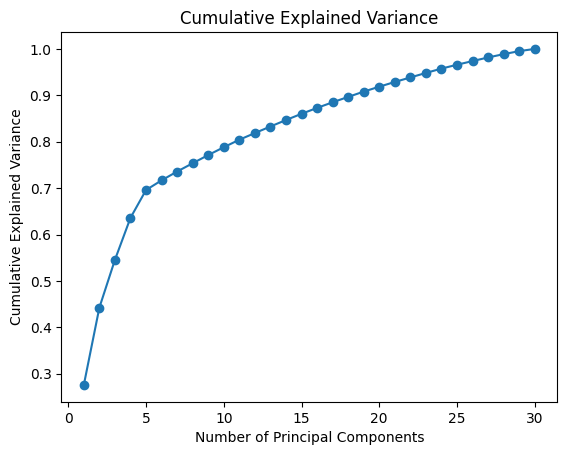

array([8.29619342, 5.01041892, 3.09603386, 2.72145353, 1.80479477,
       0.62783668, 0.57016341, 0.5378595 , 0.53061502, 0.50635668,
       0.48728484, 0.43195257, 0.42499581, 0.41901476, 0.40417979,
       0.38112746, 0.36597997, 0.3483167 , 0.34276714, 0.31959462,
       0.3057246 , 0.29372399, 0.29113309, 0.28207166, 0.24997   ,
       0.23786613, 0.23475944, 0.21308691, 0.19708467, 0.14282802])

In [ ]:
# Step 2: Determine the number of factors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Standardize the features (important for PCA)
scaler = StandardScaler()
microvan_scaled = scaler.fit_transform(X_factor)

# Create and fit the PCA model
pca = PCA()
pca.fit(microvan_scaled)

# Get the explained variance ratios
explained_variance_ratios = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_explained_variance = explained_variance_ratios.cumsum()

# Plot the explained variance ratios, want the factors to explain
# very roughly 70% or more of the variance
plt.plot(range(1, len(explained_variance_ratios) + 1), \
         cumulative_explained_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

pca.explained_variance_ # eigenvalues; want values > 1

In [ ]:
import pandas as pd
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=5, rotation='varimax')
fa.fit(X_factor)

loadings = pd.DataFrame(fa.loadings_,
                        index=X_factor.columns,
                        columns=['Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5'])


factor_scores = pd.DataFrame(fa.transform(X_factor),
                             columns=['Factor1', 'Factor2', 'Factor3', 'Factor4', 'Factor5'])

print("Rotated Factor Loadings (Top values):")
print(loadings[abs(loadings) > 0.4].fillna(''))
print("\nFactor Scores (First 5 rows):")
print(factor_scores.head())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Rotated Factor Loadings (Top values):
           Factor1   Factor2   Factor3   Factor4   Factor5
kidtrans                      0.955022                    
miniboxy            0.826631                              
lthrbetr  0.707601                                        
secbiggr            0.716387                              
safeimpt                                          0.887695
buyhghnd  0.788045                                        
pricqual  0.715282                                        
prmsound  0.663484                                        
perfimpt                                         -0.846722
tkvacatn  0.663808                      0.419552          
noparkrm            0.780419                              
homlrgst           -0.661041                              
envrminr                               -0.824706          
needbetw            0.714689                              
suvcmpct            0.799804                              
next2str          

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [ ]:
# Step 4: Create and name the factor scores

# Rename factors based on your interpretation
factor_scores.columns = ['Luxury', 'Compact Utility', 'Family', 'Green', 'Safety']

# Add factor scores to main dataframe
microvan[['Luxury', 'Compact Utility', 'Family', 'Green', 'Safety']] = factor_scores

# Confirm
print(microvan[['Luxury', 'Compact Utility', 'Family', 'Green', 'Safety']].head())


     Luxury  Compact Utility    Family     Green    Safety
0 -0.820373         0.221324  0.690847 -0.891072 -1.553473
1  0.040262         1.208604 -1.065548  0.821313  0.280028
2  0.062437        -1.703284  1.483286  0.738936  0.211700
3 -0.062822         0.247164 -1.465063 -1.301215  0.596998
4 -0.257213        -1.630527 -0.259607  0.587008 -0.179914


In [ ]:
import statsmodels.api as sm

y = microvan['mvliking']

X = microvan[['Luxury', 'Compact Utility', 'Family', 'Green', 'Safety']]

X = sm.add_constant(X)

model_factor = sm.OLS(y, X).fit()

print(model_factor.summary())

                            OLS Regression Results                            
Dep. Variable:               mvliking   R-squared:                       0.337
Model:                            OLS   Adj. R-squared:                  0.329
Method:                 Least Squares   F-statistic:                     40.13
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           2.53e-33
Time:                        03:02:48   Log-Likelihood:                -880.56
No. Observations:                 400   AIC:                             1773.
Df Residuals:                     394   BIC:                             1797.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.8425      0.110     

## Part 4

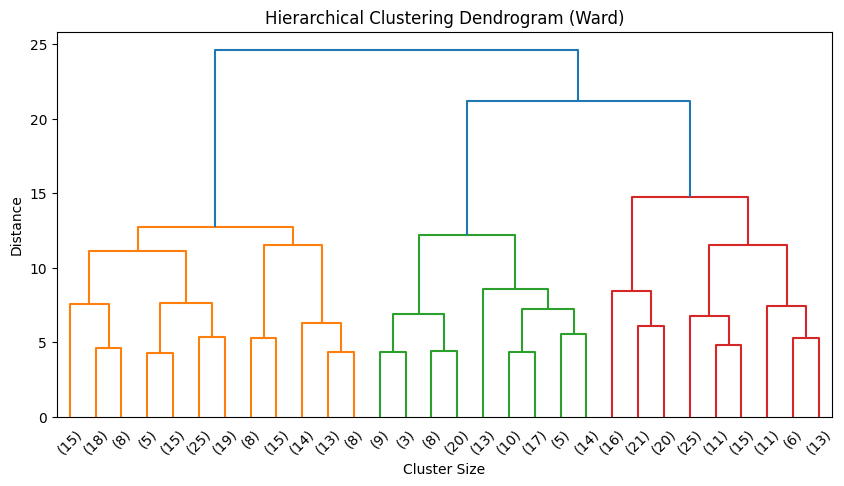

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import f_oneway


# Hierarchical Clustering

factor_cols = ['Luxury','Compact Utility','Family','Green','Safety']
X = microvan[factor_cols]

Z = linkage(X, method='ward', metric='euclidean')

plt.figure(figsize=(10,5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()



In [ ]:
# 2. K-Means Clustering

n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=25)
microvan['cluster'] = kmeans.fit_predict(X)

# Make cluster numbering start at 1 instead of 0
microvan['cluster'] = microvan['cluster'] + 1



In [ ]:

# 3. Cluster Profiles

# Factor means
cluster_means = microvan.groupby('cluster')[factor_cols].mean()
print("Factor Means by Cluster:")
print(cluster_means)

# mvliking comparison
mvliking_stats = microvan.groupby('cluster')['mvliking'].agg(['mean','std','count'])
print("\nmvliking by Cluster:")
print(mvliking_stats)

# ANOVA test
groups = [microvan[microvan['cluster']==i]['mvliking'] for i in microvan['cluster'].unique()]
f_stat, p_val = f_oneway(*groups)
print(f"\nANOVA: F={f_stat:.3f}, p={p_val:.4f}")


Factor Means by Cluster:
           Luxury  Compact Utility    Family     Green    Safety
cluster                                                         
1       -0.923749         0.037888 -0.316468 -0.470837 -0.103515
2        0.618838         1.111830  0.269752  0.353057  0.101844
3        0.588628        -1.071099  0.148497  0.265379  0.036044

mvliking by Cluster:
             mean       std  count
cluster                           
1        3.886076  2.464977    158
2        6.603448  2.276073    116
3        4.420635  2.546694    126

ANOVA: F=44.290, p=0.0000


In [ ]:

# 4. Demographic Profiles
demo_cols = ['age','income','numkids','female','educ','miles','recycle']
demo_profile = microvan.groupby('cluster')[demo_cols].mean()
print("\nDemographic Profile by Cluster:")
print(demo_profile)




Demographic Profile by Cluster:
               age      income   numkids    female      educ      miles  \
cluster                                                                   
1        32.120253   36.575949  0.689873  0.487342  2.050633  14.651899   
2        44.344828   83.146552  1.948276  0.594828  3.336207  22.232759   
3        46.055556  103.873016  1.214286  0.555556  3.261905  18.436508   

          recycle  
cluster            
1        2.987342  
2        3.094828  
3        3.055556  
